# Main figure 4: cutoff–amplitude operating window

This notebook loads the saved root-Lorentzian and echo-root-Lorentzian cutoff–amplitude simulation grids. It displays coherence-normalized fitted linewidth and a width-to-signal score. White contours mark the configurable candidate operating region. These are cached two-level simulation results, not hardware validation.

In [1]:
from pathlib import Path
import os
import sys

PROJECT_ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'echospec').is_dir())
os.environ.setdefault('MPLCONFIGDIR', str(PROJECT_ROOT / '.codex_tmp' / 'mpl'))
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LogNorm

from echospec.figures import FigureVariant, apply_figure_style, save_figure

VARIANT = FigureVariant.PAPER
apply_figure_style(VARIANT)

ROOT_PATH = PROJECT_ROOT / 'data/2d_sweep/no_echo/spectroscopy_data.npz'
ECHO_PATH = PROJECT_ROOT / 'data/2d_sweep/echo/spectroscopy_data_echo.npz'
MAX_NORMALIZED_FWHM = 2.0
MIN_SIGNAL_METRIC = 0.05

In [2]:
def load_grid(path):
    with np.load(path, allow_pickle=True) as saved:
        params = saved['params'].item()
        t2 = 1 / (1 / params['T_dephasing'] + 1 / (2 * params['T1']))
        coherence_fwhm_hz = 1 / (np.pi * t2)
        fwhm_hz = np.asarray(saved['fwhm_matrix'], dtype=float).T / (2 * np.pi)
        signal = np.asarray(saved['snr_matrix'], dtype=float).T
        width_normalized = fwhm_hz / coherence_fwhm_hz
        width_over_signal = width_normalized / np.clip(signal, 1e-6, None)
        valid = (width_normalized <= MAX_NORMALIZED_FWHM) & (signal >= MIN_SIGNAL_METRIC)
        return {
            'cutoff': np.asarray(saved['cutoff_vector'], dtype=float),
            'amplitude_mhz': np.asarray(saved['amplitudes'], dtype=float) / (2 * np.pi * 1e6),
            'width_normalized': width_normalized,
            'signal': signal,
            'width_over_signal': width_over_signal,
            'valid': valid,
            'params': params,
            't2_us': t2 / 1e-6,
            'coherence_fwhm_khz': coherence_fwhm_hz / 1e3,
        }

root = load_grid(ROOT_PATH)
echo = load_grid(ECHO_PATH)
print(f"T2 = {root['t2_us']:.2f} us; coherence FWHM = {root['coherence_fwhm_khz']:.2f} kHz")
print(f"Root valid fraction: {root['valid'].mean():.3f}")
print(f"Echo valid fraction: {echo['valid'].mean():.3f}")

T2 = 15.00 us; coherence FWHM = 21.22 kHz
Root valid fraction: 0.044
Echo valid fraction: 0.154


[PosixPath('/Users/asafsolonnikov/Developer/amplitude-robust-spectroscopy/figures/paper/04_operating_window.png'),
 PosixPath('/Users/asafsolonnikov/Developer/amplitude-robust-spectroscopy/figures/paper/04_operating_window.svg')]

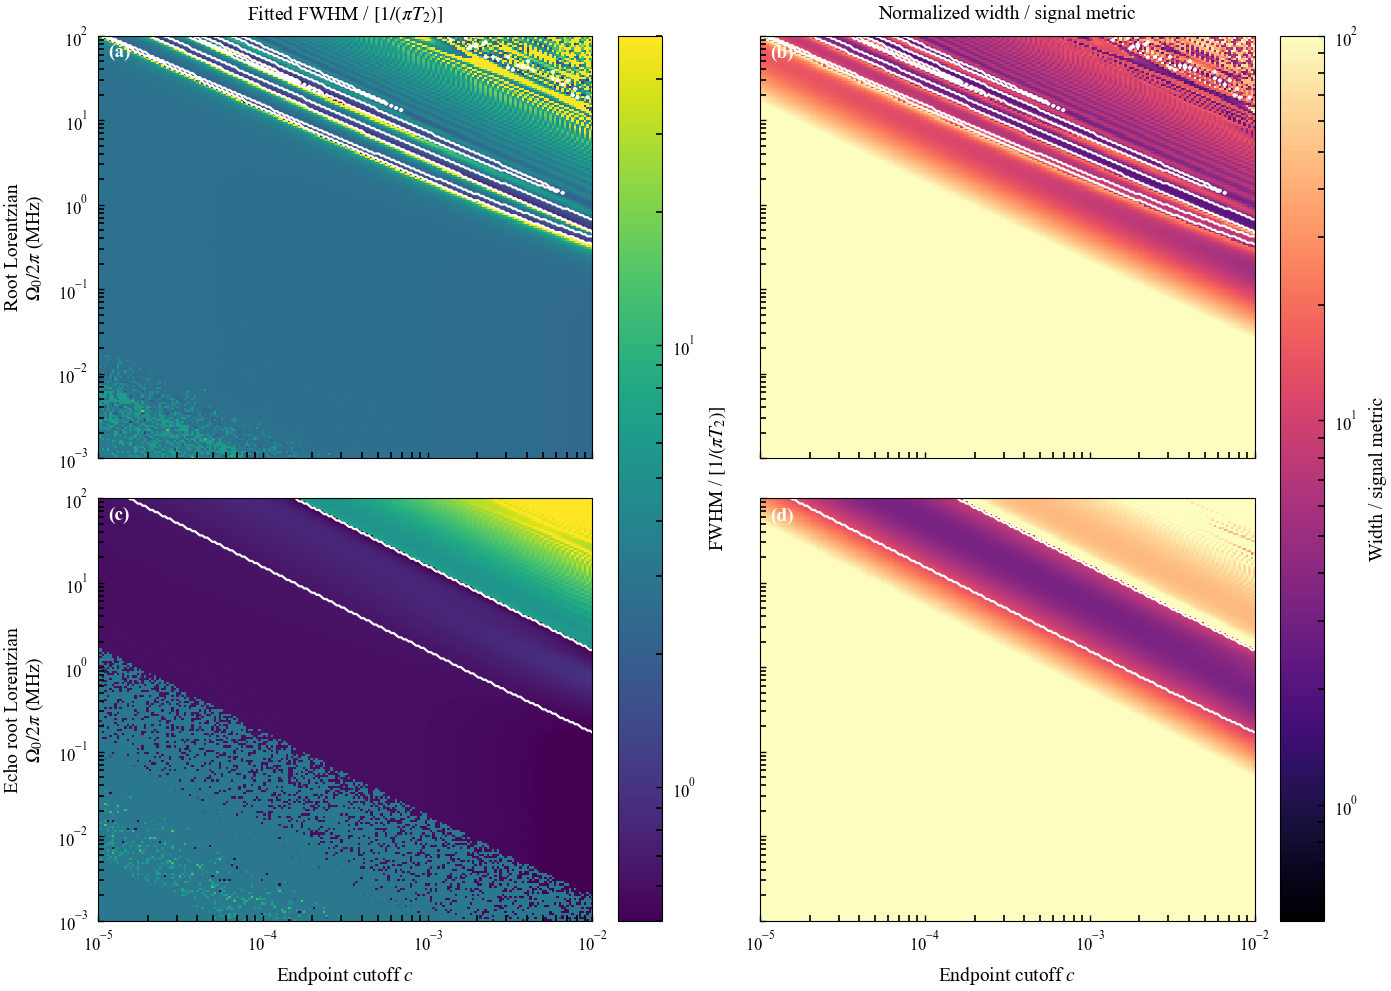

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(7.0, 5.0), sharex=True, sharey=True, constrained_layout=True)
datasets = [('Root Lorentzian', root), ('Echo root Lorentzian', echo)]
images = [None, None]

for row, (row_name, data) in enumerate(datasets):
    cutoff = data['cutoff']
    amplitude = data['amplitude_mhz']
    matrices = [data['width_normalized'], data['width_over_signal']]
    norms = [LogNorm(vmin=0.5, vmax=50), LogNorm(vmin=0.5, vmax=100)]
    cmaps = ['viridis', 'magma']

    for col, (matrix, norm, cmap) in enumerate(zip(matrices, norms, cmaps)):
        ax = axes[row, col]
        images[col] = ax.pcolormesh(cutoff, amplitude, np.clip(matrix, norm.vmin, norm.vmax), shading='auto', cmap=cmap, norm=norm, rasterized=True)
        ax.contour(cutoff, amplitude, data['valid'].astype(float), levels=[0.5], colors='white', linewidths=0.8)
        ax.set_xscale('log')
        ax.set_yscale('log')
        ax.set_xlim(cutoff.min(), cutoff.max())
        ax.set_ylim(amplitude.min(), amplitude.max())
        if col == 0:
            ax.set_ylabel(row_name + '\n' + r'$\Omega_0/2\pi$ (MHz)')

axes[0, 0].set_title(r'Fitted FWHM / $[1/(\pi T_2)]$')
axes[0, 1].set_title('Normalized width / signal metric')
axes[1, 0].set_xlabel('Endpoint cutoff $c$')
axes[1, 1].set_xlabel('Endpoint cutoff $c$')

for col, label in enumerate([r'FWHM / $[1/(\pi T_2)]$', 'Width / signal metric']):
    colorbar = fig.colorbar(images[col], ax=axes[:, col], pad=0.02)
    colorbar.set_label(label)

for label, ax in zip(['(a)', '(b)', '(c)', '(d)'], axes.flat):
    ax.text(0.02, 0.98, label, transform=ax.transAxes, ha='left', va='top', color='white', fontweight='bold')

saved = save_figure(fig, '04_operating_window', variant=VARIANT)
saved

### Operating-region definition

The white contour is a screening rule, not a universal optimum. A point is retained when the fitted FWHM is at most `MAX_NORMALIZED_FWHM` times $1/(\pi T_2)$ and the saved signal metric is at least `MIN_SIGNAL_METRIC`. The thresholds are declared near the top of the notebook so the paper can report and reproduce the exact choice. The saved quantity is called `snr_matrix` in the legacy files, but it should be described as a fit-derived signal metric unless its noise normalization is independently verified.